In [3]:
import sqlite3 as sql
import pandas as pd

In [4]:
conn = sql.connect("chinook.db")

def sql_query(q):
    return pd.read_sql_query(q, conn)

In [5]:
sql_query("select * from sqlite_master")

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


In [6]:
pd.read_sql_query('select * from sqlite_master',conn)

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


In [7]:
sql_query("select * from sqlite_master where type = 'table'")

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


In [18]:
q = """select * from employee
"""
sql_query(q)

,employee_id,last_name,first_name,title,reports_to,birthdate,hire_date,address,city,state,country,postal_code,phone,fax,email
0,1,Adams,Andrew,General Manager,NaN,1962-02-18 00:00:00,2016-08-14 00:00:00,11120 Jasper Ave NW,Edmonton,AB,Canada,T5K 2N1,+1 (780) 428-9482,+1 (780) 428-3457,andrew@chinookcorp.com
1,2,Edwards,Nancy,Sales Manager,1.0,1958-12-08 00:00:00,2016-05-01 00:00:00,825 8 Ave SW,Calgary,AB,Canada,T2P 2T3,+1 (403) 262-3443,+1 (403) 262-3322,nancy@chinookcorp.com
2,3,Peacock,Jane,Sales Support Agent,2.0,1973-08-29 00:00:00,2017-04-01 00:00:00,1111 6 Ave SW,Calgary,AB,Canada,T2P 5M5,+1 (403) 262-3443,+1 (403) 262-6712,jane@chinookcorp.com
3,4,Park,Margaret,Sales Support Agent,2.0,1947-09-19 00:00:00,2017-05-03 00:00:00,683 10 Street SW,Calgary,AB,Canada,T2P 5G3,+1 (403) 263-4423,+1 (403) 263-4289,margaret@chinookcorp.com
4,5,Johnson,Steve,Sales Support Agent,2.0,1965-03-03 00:00:00,2017-10-17 00:00:00,7727B 41 Ave,Calgary,AB,Canada,T3B 1Y7,1 (780) 836-9987,1 (780) 836-9543,steve@chinookcorp.com
5,6,Mitchell,Michael,IT Manager,1.0,1973-07-01 00:00:00,2016-10-17 00:00:00,5827 Bowness Road NW,Calgary,AB,Canada,T3B 0C5,+1 (403) 246-9887,+1 (403) 246-9899,michael@chinookcorp.com
6,7,King,Robert,IT Staff,6.0,1970-05-29 00:00:00,2017-01-02 00:00:00,590 Columbia Boulevard West,Lethbridge,AB,Canada,T1K 5N8,+1 (403) 456-9986,+1 (403) 456-8485,robert@chinookcorp.com
7,8,Callahan,Laura,IT Staff,6.0,1968-01-09 00:00:00,2017-03-04 00:00:00,923 7 ST NW,Lethbridge,AB,Canada,T1H 1Y8,+1 (403) 467-3351,+1 (403) 467-8772,laura@chinookcorp.com



### Q1 Write a query to list the top 10 genres with the highest number of tracks. (Show in bar plot)



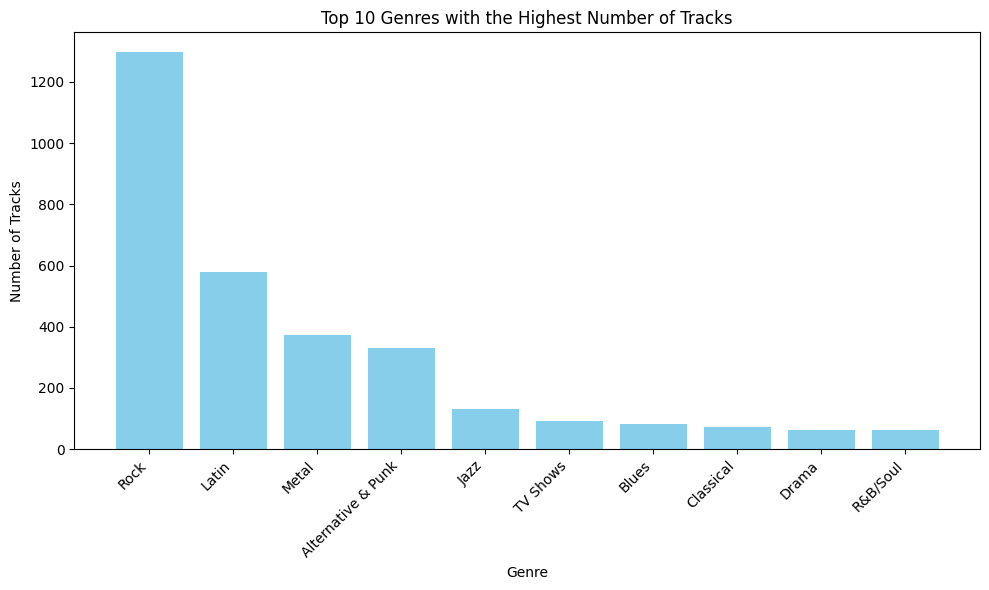

In [14]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect("chinook.db")

# Run the query
df = pd.read_sql_query("""
SELECT 
    g.name AS Genre, 
    COUNT(t.track_id) AS TrackCount
FROM genre g
JOIN track t 
    ON g.genre_id = t.genre_id
GROUP BY g.genre_id, g.name
ORDER BY TrackCount DESC
LIMIT 10;
""", conn)

# Plot
plt.figure(figsize=(10,6))
plt.bar(df['Genre'], df['TrackCount'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Genre')
plt.ylabel('Number of Tracks')
plt.title('Top 10 Genres with the Highest Number of Tracks')
plt.tight_layout()
plt.show()


## Q2. Write a query to list the top 10 albums that contain the most tracks.

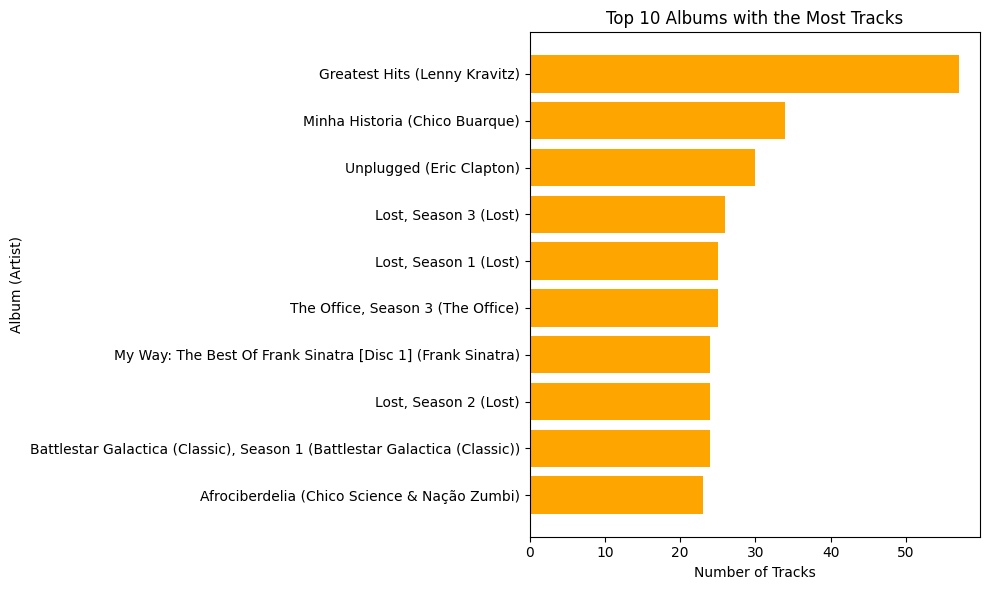

In [16]:
df = pd.read_sql_query("""
SELECT 
    al.title AS Album, 
    ar.name AS Artist,
    COUNT(t.track_id) AS TrackCount
FROM album al
JOIN artist ar 
    ON al.artist_id = ar.artist_id
JOIN track t 
    ON al.album_id = t.album_id
GROUP BY al.album_id, al.title, ar.name
ORDER BY TrackCount DESC
LIMIT 10;
""", conn)

plt.figure(figsize=(10,6))
plt.barh(df['Album'] + " (" + df['Artist'] + ")", df['TrackCount'], color='orange')
plt.xlabel('Number of Tracks')
plt.ylabel('Album (Artist)')
plt.title('Top 10 Albums with the Most Tracks')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Q3. Write a query to find the top 10 customers who spent the most money.

In [17]:
q = '''
SELECT 
c.first_name || ' ' || c.last_name AS Customer,
c.country, ROUND(SUM(i.total), 2) AS TotalSpent
FROM customer c
JOIN invoice i 
    ON c.customer_id = i.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name, c.country
ORDER BY TotalSpent DESC
LIMIT 10'''
sql_query(q)

,Customer,country,TotalSpent
0,František Wichterlová,Czech Republic,144.54
1,Helena Holý,Czech Republic,128.70
2,Hugh O'Reilly,Ireland,114.84
3,Manoj Pareek,India,111.87
4,Luís Gonçalves,Brazil,108.90
5,Fernanda Ramos,Brazil,106.92
6,João Fernandes,Portugal,102.96
7,François Tremblay,Canada,99.99
8,Wyatt Girard,France,99.99
9,Jack Smith,USA,98.01


## Q4. Write a query to find the top 5 artists who generated the highest revenue from track sales.

In [18]:
q = '''
SELECT 
ar.name AS Artist,
ROUND(SUM(il.unit_price * il.quantity), 2) AS TotalRevenue
FROM artist ar
JOIN album al 
ON ar.artist_id = al.artist_id
JOIN track t 
ON al.album_id = t.album_id
JOIN invoice_line il 
ON t.track_id = il.track_id
GROUP BY ar.artist_id, ar.name
ORDER BY TotalRevenue DESC
LIMIT 5'''

sql_query(q)

,Artist,TotalRevenue
0,Queen,190.08
1,Jimi Hendrix,185.13
2,Nirvana,128.70
3,Red Hot Chili Peppers,128.70
4,Pearl Jam,127.71


## Q5. Countries by Average Revenue per Invoice

In [19]:
q = '''
SELECT 
c.country AS Country,
ROUND(AVG(i.total), 2) AS AvgRevenuePerInvoice
FROM customer c
JOIN invoice i 
ON c.customer_id = i.customer_id
GROUP BY c.country
ORDER BY AvgRevenuePerInvoice DESC'''
sql_query(q)

,Country,AvgRevenuePerInvoice
0,Czech Republic,9.11
1,Spain,8.91
2,Ireland,8.83
3,United Kingdom,8.77
4,India,8.72
5,Belgium,8.63
6,Germany,8.16
7,Australia,8.12
8,Norway,8.03
9,USA,7.94


## Q6. Write a query to find the media type with number of tracks.


In [20]:
q = '''
SELECT 
    t.name AS Track,
    ar.name AS Artist,
    SUM(il.quantity) AS TotalPurchases
FROM track t
JOIN album al 
    ON t.album_id = al.album_id
JOIN artist ar 
    ON al.artist_id = ar.artist_id
JOIN invoice_line il 
    ON t.track_id = il.track_id
GROUP BY t.track_id, t.name, ar.name
ORDER BY TotalPurchases DESC
LIMIT 10'''
sql_query(q)


,Track,Artist,TotalPurchases
0,War Pigs,Cake,31
1,Are You Experienced?,Jimi Hendrix,14
2,Highway Chile,Jimi Hendrix,14
3,Put The Finger On You,AC/DC,13
4,Third Stone From The Sun,Jimi Hendrix,13
5,Hey Joe,Jimi Hendrix,13
6,Love Or Confusion,Jimi Hendrix,12
7,Radio/Video,System Of A Down,12
8,Dead And Broken,Godsmack,11
9,Foxy Lady,Jimi Hendrix,11


## Q7. Which artists have released tracks in more than one genre?

In [21]:
q = '''
SELECT 
    mt.name AS MediaType,
    ROUND(SUM(il.unit_price * il.quantity), 2) AS TotalRevenue
FROM media_type mt
JOIN track t 
    ON mt.media_type_id = t.media_type_id
JOIN invoice_line il 
    ON t.track_id = il.track_id
GROUP BY mt.media_type_id, mt.name
ORDER BY TotalRevenue DESC'''
sql_query(q)


,MediaType,TotalRevenue
0,MPEG audio file,4216.41
1,Protected AAC audio file,434.61
2,Purchased AAC audio file,34.65
3,AAC audio file,20.79
4,Protected MPEG-4 video file,2.97


## Q8. Write a query to list the top 10 longest tracks by duration.

In [22]:
q = '''
SELECT 
    c.country AS Country,
    ROUND(SUM(i.total), 2) AS TotalRevenue
FROM customer c
JOIN invoice i 
    ON c.customer_id = i.customer_id
GROUP BY c.country
ORDER BY TotalRevenue DESC
LIMIT 5'''
sql_query(q)

,Country,TotalRevenue
0,USA,1040.49
1,Canada,535.59
2,Brazil,427.68
3,France,389.07
4,Germany,334.62


## Q9. Top 5 Revenue Share percentage by Artist (Pie Chart)

In [23]:
q = '''
SELECT 
    Country,
    Customer,
    TotalSpent
FROM (
    SELECT 
        c.country AS Country,
        c.first_name || ' ' || c.last_name AS Customer,
        ROUND(SUM(i.total), 2) AS TotalSpent,
        RANK() OVER (PARTITION BY c.country ORDER BY SUM(i.total) DESC) AS rank_in_country
    FROM customer c
    JOIN invoice i 
        ON c.customer_id = i.customer_id
    GROUP BY c.country, c.customer_id, c.first_name, c.last_name
) ranked
WHERE rank_in_country <= 5
ORDER BY Country, TotalSpent DESC'''
sql_query(q)


,Country,Customer,TotalSpent
0,Argentina,Diego Gutiérrez,39.60
1,Australia,Mark Taylor,81.18
2,Austria,Astrid Gruber,69.30
3,Belgium,Daan Peeters,60.39
4,Brazil,Luís Gonçalves,108.90
5,Brazil,Fernanda Ramos,106.92
6,Brazil,Roberto Almeida,82.17
7,Brazil,Alexandre Rocha,69.30
8,Brazil,Eduardo Martins,60.39
9,Canada,François Tremblay,99.99


## Q10. Revenue by Genre (Rock, Latin, Metal) in Each Country (Stacked Column Chart)

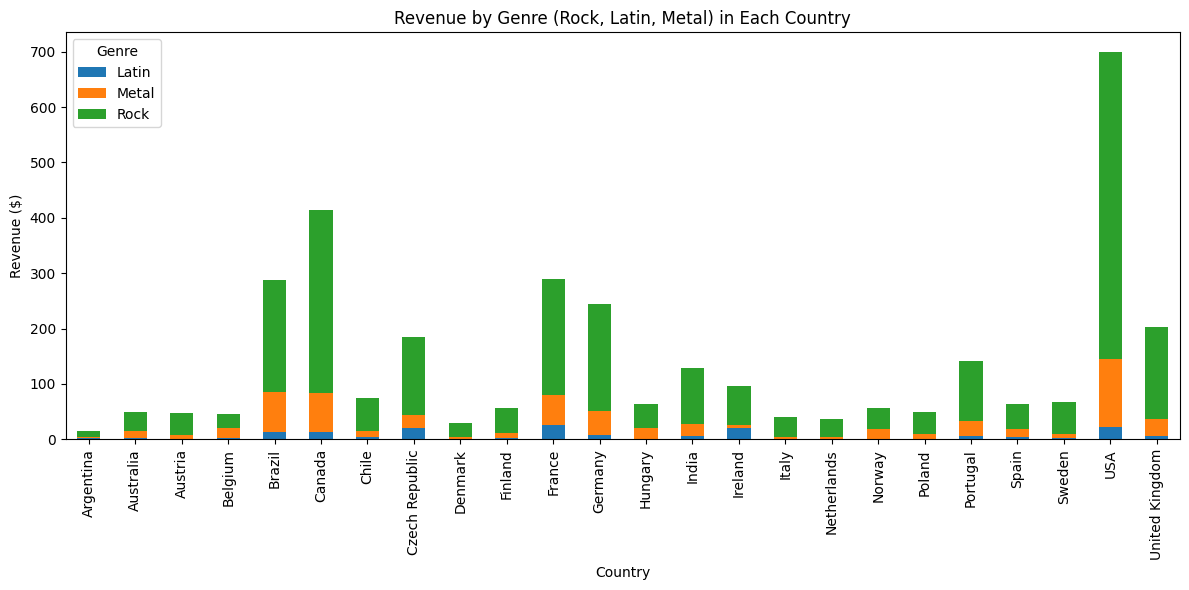

In [24]:
df = pd.read_sql_query("""
SELECT 
    c.country AS Country,
    g.name AS Genre,
    ROUND(SUM(il.unit_price * il.quantity), 2) AS TotalRevenue
FROM customer c
JOIN invoice i 
    ON c.customer_id = i.customer_id
JOIN invoice_line il 
    ON i.invoice_id = il.invoice_id
JOIN track t 
    ON il.track_id = t.track_id
JOIN genre g 
    ON t.genre_id = g.genre_id
WHERE g.name IN ('Rock', 'Latin', 'Metal')
GROUP BY c.country, g.name
ORDER BY c.country, g.name;
""", conn)

# Pivot for stacked chart
pivot_df = df.pivot(index='Country', columns='Genre', values='TotalRevenue').fillna(0)

# Plot
pivot_df.plot(kind='bar', stacked=True, figsize=(12,6))
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.title('Revenue by Genre (Rock, Latin, Metal) in Each Country')
plt.xticks(rotation=90)
plt.legend(title='Genre')
plt.tight_layout()
plt.show()
